In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
# XLSX-Datei einlesen
df = pd.read_excel(r'C:\Users\miria\creditcard_psp\data\raw\PSP_Jan_Feb_2019.xlsx', index_col=0)

# Überblick über die Struktur und Datentypen
print("==== Dataset Info ====")
print(df.info())

# Erste und letzte 5 Zeilen anzeigen
print("==== Erste 5 Zeilen ====")
print(df.head(5))
print("==== Letzte 5 Zeilen ====")
print(df.tail(5))

# Statistische Zusammenfassung der numerischen Spalten
print("\n==== Statistische Zusammenfassung ====")
print(df.describe())

==== Dataset Info ====
<class 'pandas.core.frame.DataFrame'>
Int64Index: 50410 entries, 0 to 50409
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   tmsp        50410 non-null  datetime64[ns]
 1   country     50410 non-null  object        
 2   amount      50410 non-null  int64         
 3   success     50410 non-null  int64         
 4   PSP         50410 non-null  object        
 5   3D_secured  50410 non-null  int64         
 6   card        50410 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 3.1+ MB
None
==== Erste 5 Zeilen ====
                 tmsp  country  amount  success         PSP  3D_secured  \
0 2019-01-01 00:01:11  Germany      89        0     UK_Card           0   
1 2019-01-01 00:01:17  Germany      89        1     UK_Card           0   
2 2019-01-01 00:02:49  Germany     238        0     UK_Card           1   
3 2019-01-01 00:03:13  Germany     238

In [4]:
# Anzahl fehlender Werte pro Spalte
print("\n==== Fehlende Werte pro Spalte ====")
missing_values = df.isnull().sum()
print(missing_values)


==== Fehlende Werte pro Spalte ====
tmsp          0
country       0
amount        0
success       0
PSP           0
3D_secured    0
card          0
dtype: int64


In [5]:
# Anzahl der Duplikate
duplicates = df.duplicated().sum()
print("\n==== Anzahl Duplikate ====")
print(duplicates)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\n==== Numerische Spalten ====")
print(numeric_cols)

object_cols = df.select_dtypes(include=[object]).columns.tolist()
print("\n==== Object Spalten ====")
print(object_cols)

# Überprüfung auf unterschiedliche Schreibweisen in einer Spalte
print("\n==== Schreibweisen in einer Spalte ====")
print(df['country'].value_counts())
print(df['PSP'].value_counts())
print(df['card'].value_counts())


==== Anzahl Duplikate ====
81

==== Numerische Spalten ====
['amount', 'success', '3D_secured']

==== Object Spalten ====
['country', 'PSP', 'card']

==== Schreibweisen in einer Spalte ====
Germany        30233
Switzerland    10338
Austria         9839
Name: country, dtype: int64
UK_Card       26459
Simplecard    12446
Moneycard      8297
Goldcard       3208
Name: PSP, dtype: int64
Master    29002
Visa      11640
Diners     9768
Name: card, dtype: int64


In [6]:
for col in numeric_cols:
    # Berechne den Z-Score für die Spalte (nur nicht fehlende Werte)
    z_scores = np.abs(stats.zscore(df[col].dropna()))
    # Definiere Ausreißer als Werte mit einem Z-Score > 3
    outliers = df[z_scores > 3]
    print(f"Anzahl der Ausreißer in '{col}': {outliers.shape[0]}")

Anzahl der Ausreißer in 'amount': 83
Anzahl der Ausreißer in 'success': 0
Anzahl der Ausreißer in '3D_secured': 0


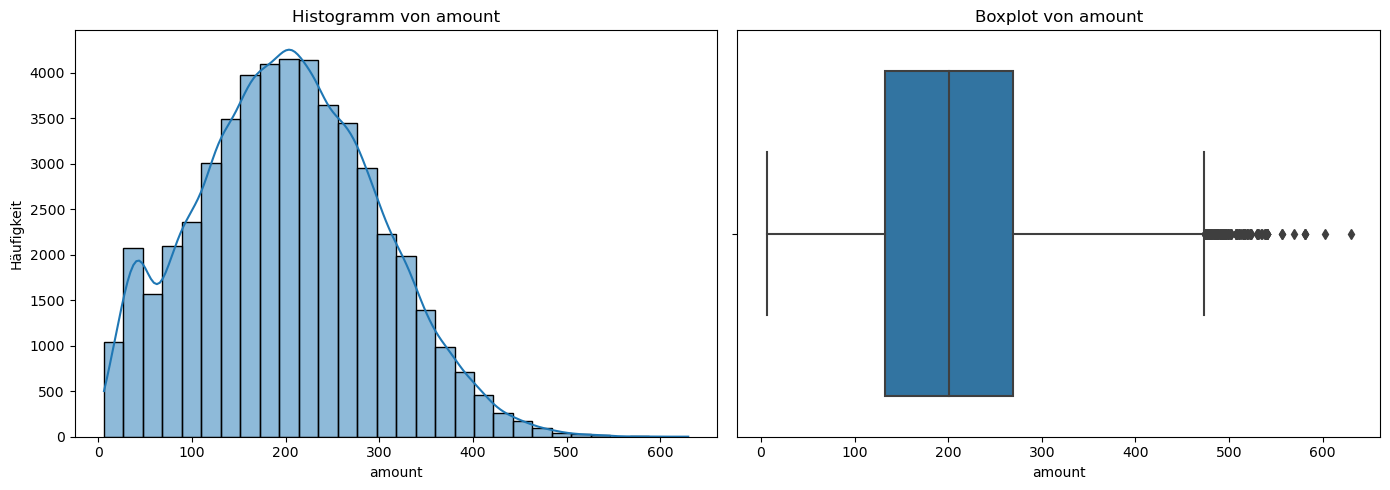

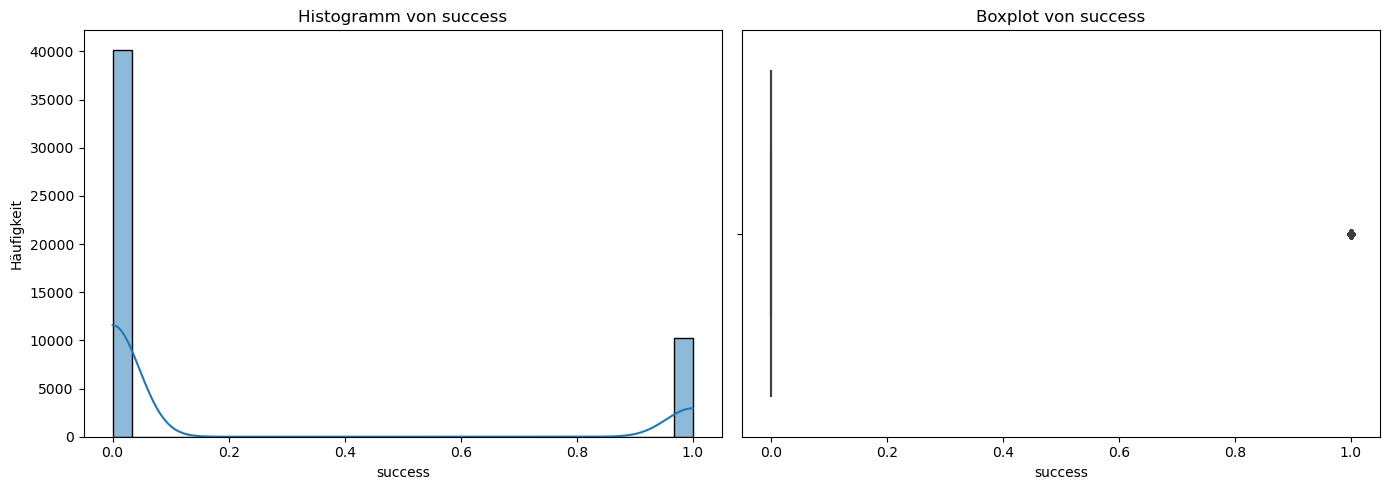

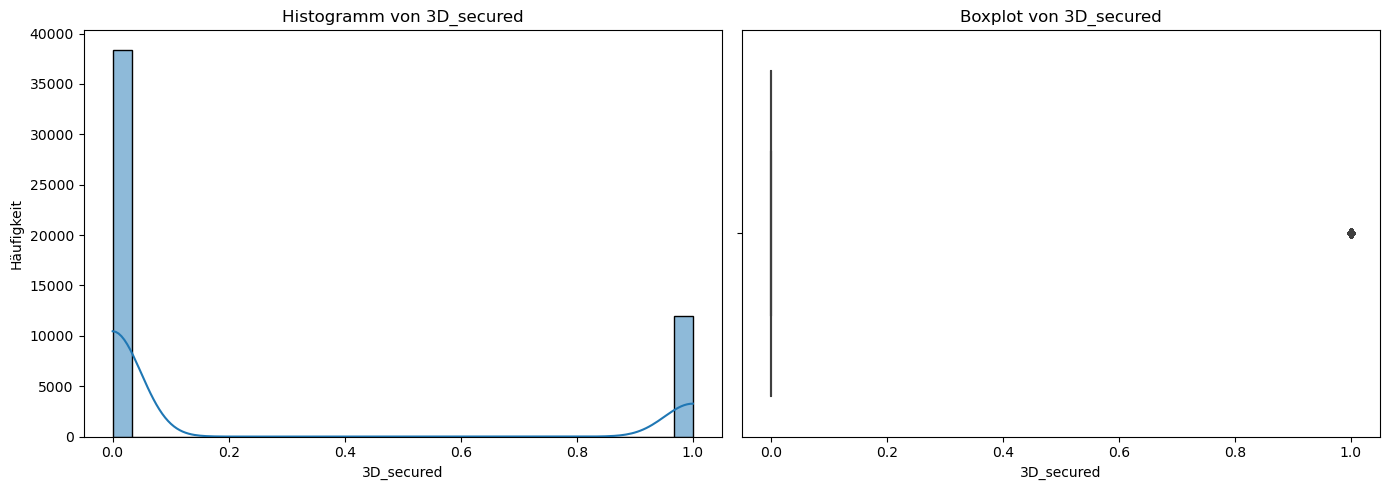

In [7]:
for col in numeric_cols:
    plt.figure(figsize=(14, 5))
    
    # Histogramm mit Dichtekurve
    plt.subplot(1, 2, 1)
    sns.histplot(df[col].dropna(), kde=True, bins=30)
    plt.title(f'Histogramm von {col}')
    plt.xlabel(col)
    plt.ylabel('Häufigkeit')
    
    # Boxplot zur Ausreißer-Erkennung
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot von {col}')
    
    plt.tight_layout()
    plt.show()

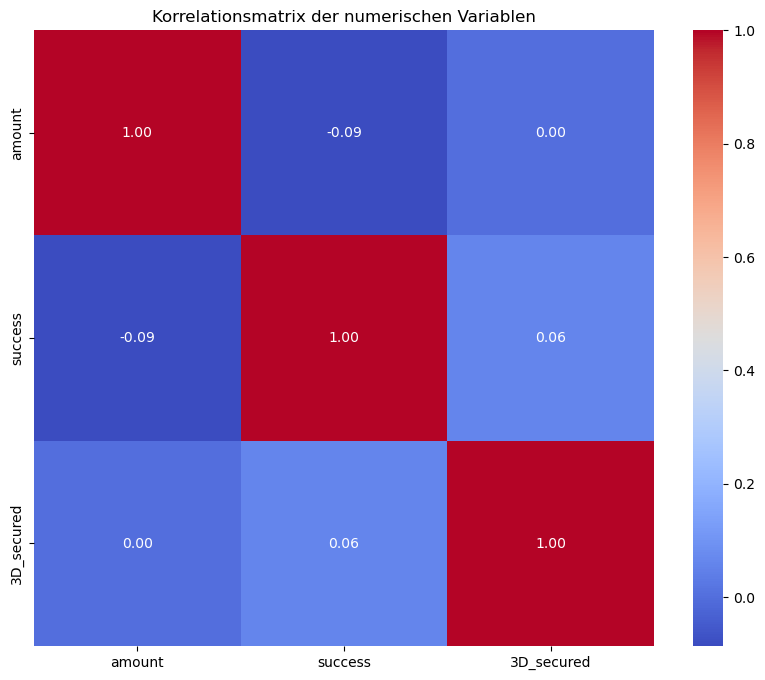

In [8]:
# Korrelationsmatrix als Heatmap
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Korrelationsmatrix der numerischen Variablen')
plt.show()

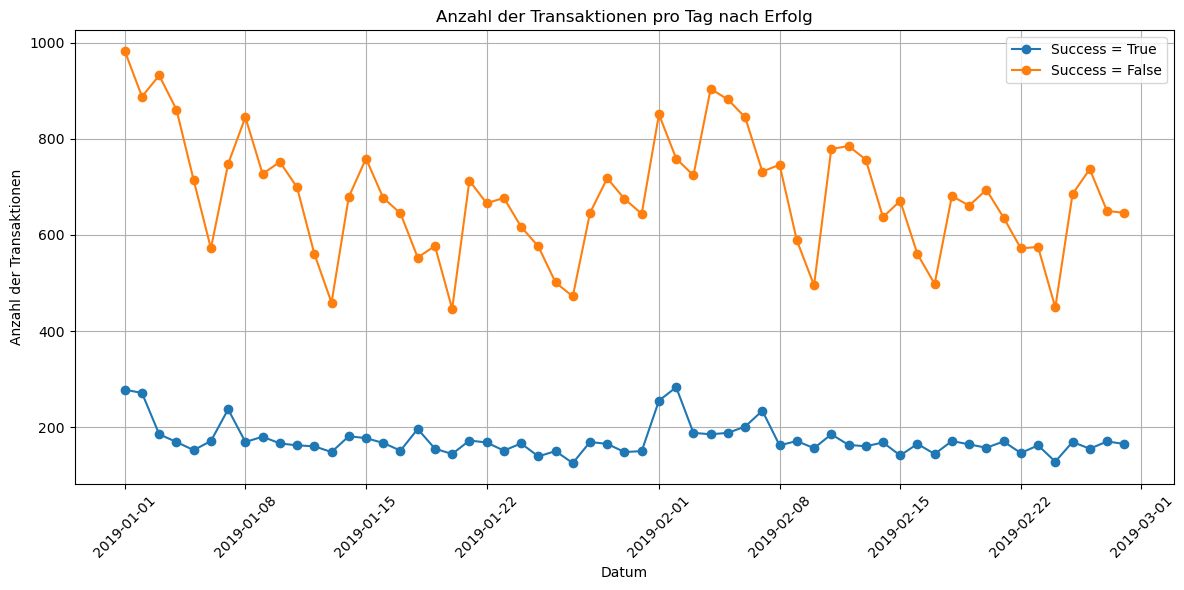

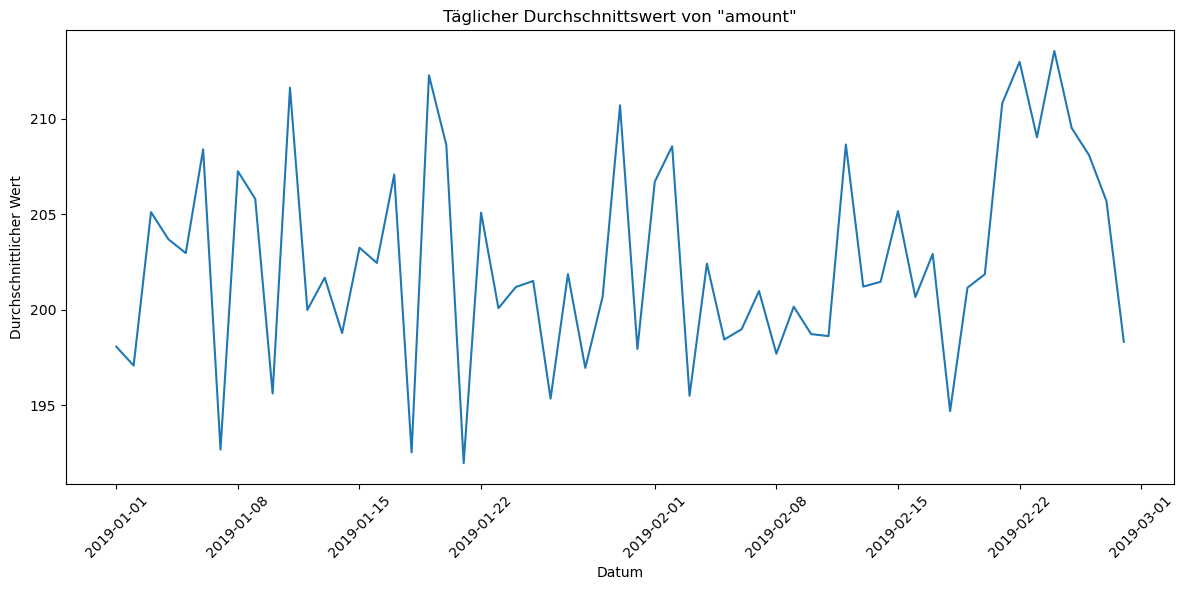

In [9]:
# Konvertiere die 'tmsp'-Spalte in ein Datetime-Format:
df['tmsp'] = pd.to_datetime(df['tmsp'], errors='coerce')

# Datum extrahieren
df['date'] = df['tmsp'].dt.date

# Angenommen, df enthält die Spalten 'date' und 'success'
# Gruppiere nach 'date' und 'success', zähle die Transaktionen und wandle das Ergebnis um
daily_counts_success = df.groupby(['date', 'success']).size().unstack(fill_value=0)

# Plot: Anzahl der Transaktionen pro Tag getrennt nach 'success'
plt.figure(figsize=(12, 6))
plt.grid(True)
plt.plot(daily_counts_success.index, daily_counts_success[1], marker='o', label='Success = True')
plt.plot(daily_counts_success.index, daily_counts_success[0], marker='o', label='Success = False')
plt.xlabel('Datum')
plt.ylabel('Anzahl der Transaktionen')
plt.title('Anzahl der Transaktionen pro Tag nach Erfolg')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# Beispiel 2: Falls du weitere zeitbasierte Kennzahlen darstellen möchtest, z. B. Mittelwert einer numerischen Variable
# Angenommen, es gibt eine numerische Spalte 'value', die aggregiert werden soll:
if 'amount' in df.columns:
    daily_mean = df.groupby('date')['amount'].mean()

    plt.figure(figsize=(12, 6))
    sns.lineplot(x=daily_mean.index, y=daily_mean.values)
    plt.xlabel('Datum')
    plt.ylabel('Durchschnittlicher Wert')
    plt.title('Täglicher Durchschnittswert von "amount"')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [10]:
from ydata_profiling import ProfileReport

# 7. Erstelle einen umfassenden Datenqualitätsreport mit ydata-profiling
profile = ProfileReport(df, title="Datenqualitätsreport", explorative=True)
# Speichere den Report als HTML-Datei 
profile.to_file(r'C:\Users\miria\PSP\data\processed\data_quality_report.html')

C:\Users\miria\anaconda3\Lib\site-packages\ydata_profiling\profile_report.py:365: UserWarning: Try running command: 'pip install --upgrade Pillow' to avoid ValueError
  warnings.warn(


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:02<00:00,  2.72it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [20]:
# 1. Timestamp runden
df['tmsp']     = pd.to_datetime(df['tmsp'], errors='coerce')
df['tmsp_min'] = df['tmsp'].dt.floor('T')

# 2. Gruppenschlüssel definieren
group_cols = ['tmsp_min', 'country', 'amount']

# 3. Flag: wurde mehrfach mit verschiedenen Karten probiert?
df['multiple_cards'] = df.groupby(group_cols)['card'] \
                         .transform(lambda x: x.nunique() > 1)

# 4. Flag pro Karte: war diese Karte innerhalb der Transaktion erfolgreich?
df['success_per_card'] = df.groupby(group_cols + ['card'])['success'] \
                           .transform('any')

# 5.Transaktionen mit mehreren Karten ausgeben
result = (df
          .drop_duplicates(subset=group_cols + ['card'])
          .loc[:, group_cols + ['card', 'multiple_cards', 'success_per_card']]
         )
result_multi = result[result['multiple_cards']]

print(result_multi)

                 tmsp_min  country  amount    card  multiple_cards  \
14836 2019-01-17 00:06:00  Germany     240  Diners            True   
14838 2019-01-17 00:06:00  Germany     240  Master            True   

       success_per_card  
14836             False  
14838             False  
